# LBP + SVM : dossiers train, validation et test

Exécuter avec unikin_ml dans l’ordre. Aucune installation.
La séparation test existante est conservée. Les anciennes données d’apprentissage sont divisées en train et validation fixes. Les images sont copiées, jamais déplacées, dans un nouveau dossier horodaté. La démonstration accepte uniquement les fichiers du dossier test correspondant à cette exécution.

La validation choisit les paramètres ; le SVM final apprend seulement sur train. Le test déjà consulté lors de K-means reste un test réutilisé. Les quasi-doublons et les découpes apparentées restent une limite non résolue par le simple classement en dossiers.


## 1. Inventaire
Le chemin Windows est conservé. Aucune installation de paquet.

In [1]:
from pathlib import Path
from collections import Counter

DOSSIER = Path(r"C:\Users\user\Desktop\RDF\NEU-CLS-64")
EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

if not DOSSIER.is_dir():
    raise FileNotFoundError(f"Dossier introuvable : {DOSSIER}")

fichiers = sorted(
    f for f in DOSSIER.rglob("*")
    if f.is_file() and f.suffix.lower() in EXTENSIONS
)

effectifs = Counter(
    str(f.parent.relative_to(DOSSIER))
    for f in fichiers
)

print("Images par dossier :")
for dossier, nombre in sorted(effectifs.items()):
    print(f"{dossier} : {nombre}")

print(f"\nTotal : {len(fichiers)} images")

print("\nExemples de fichiers :")
for fichier in fichiers[:6]:
    print(fichier.relative_to(DOSSIER))
if not fichiers:
    raise ValueError("Aucune image trouvée.")
if any(f.parent.parent != DOSSIER for f in fichiers):
    raise ValueError("Structure attendue : dossier/categorie/image. Vérifier les sous-dossiers.")


Images par dossier :
cr : 1210
gg : 296
in : 775
pa : 1148
ps : 797
rp : 200
rs : 1589
sc : 773
sp : 438

Total : 7226 images

Exemples de fichiers :
cr\1.jpg
cr\10.jpg
cr\100.jpg
cr\1000.jpg
cr\1001.jpg
cr\1002.jpg


## 2. Exemples
Ces images illustrent les catégories ; elles ne mesurent pas les performances.

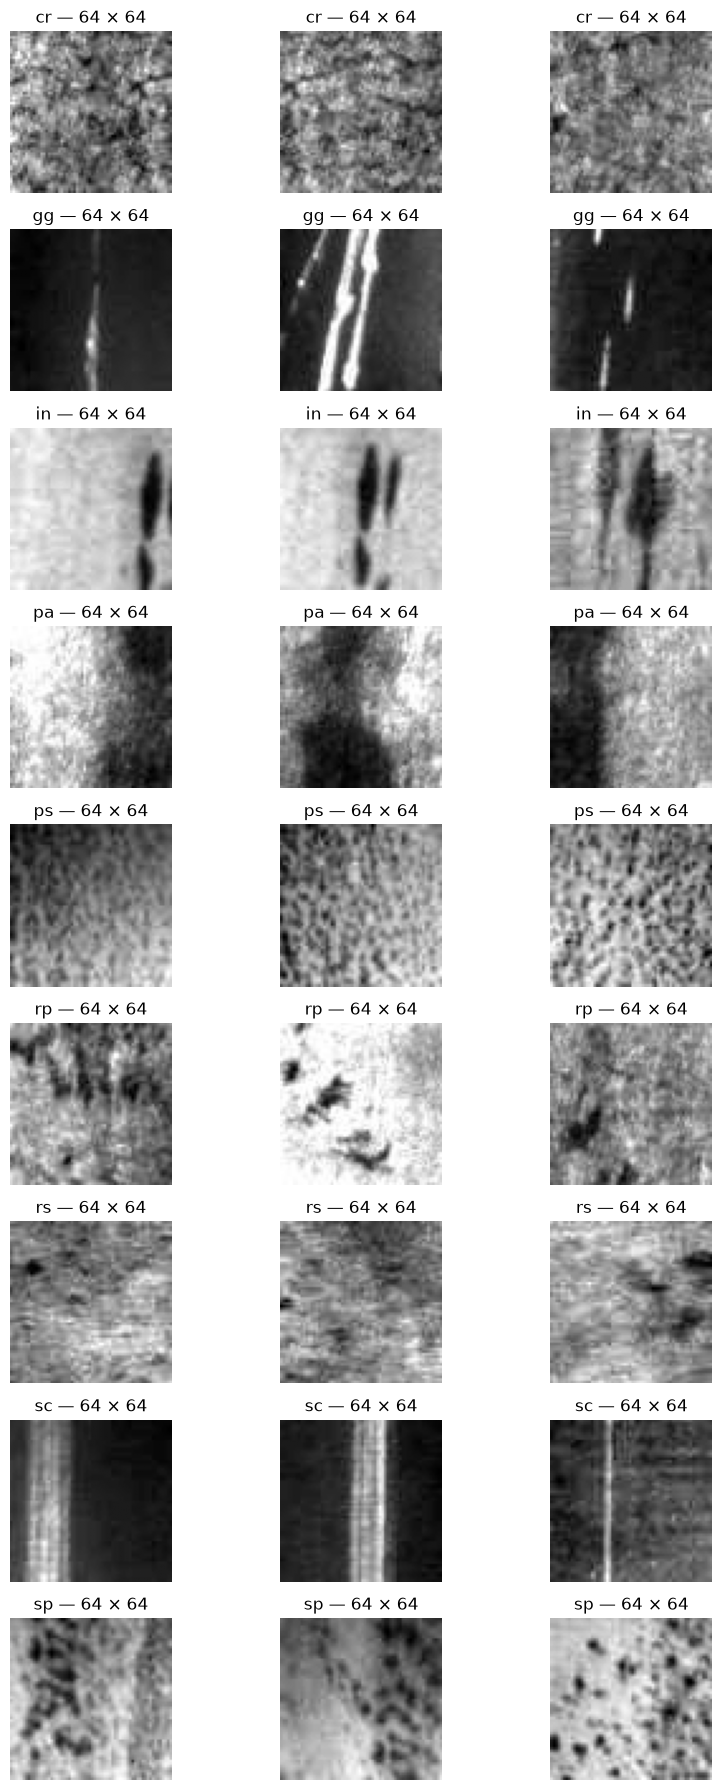

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

categories = sorted({f.parent for f in fichiers})

fig, axes = plt.subplots(
    len(categories), 3,
    figsize=(9, 2 * len(categories)),
    squeeze=False
)

for ligne, categorie in enumerate(categories):
    exemples = [f for f in fichiers if f.parent == categorie][:3]

    for colonne, axe in enumerate(axes[ligne]):
        axe.axis("off")

        if colonne < len(exemples):
            chemin = exemples[colonne]

            with Image.open(chemin) as image:
                axe.imshow(image.convert("L"), cmap="gray")
                axe.set_title(
                    f"{categorie.name} — {image.width} × {image.height}"
                )

plt.tight_layout()
plt.show()

## 3. Descripteur LBP
P=8, R=1, uniform, 10 fréquences. La bordure est exclue. Ce calcul est conservé.

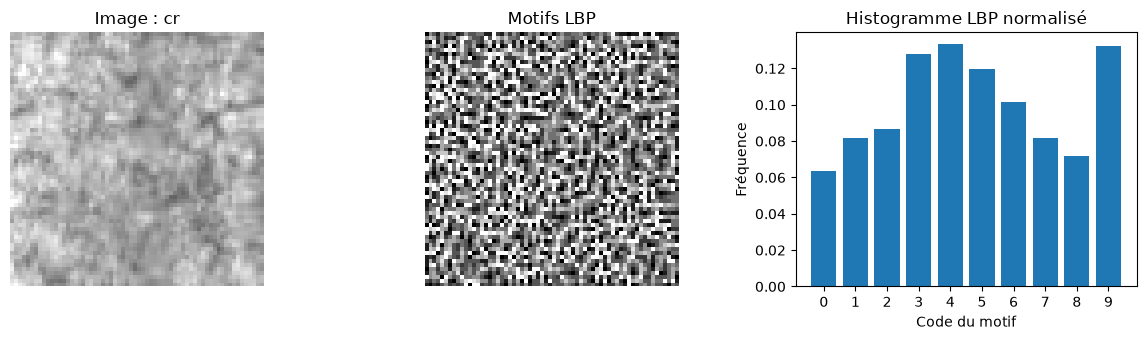

Vecteur de caractéristiques : [0.0637 0.0817 0.0869 0.128  0.1332 0.1194 0.1015 0.0817 0.0715 0.1324]
Somme des fréquences : 1.0


In [3]:
import numpy as np
from skimage.feature import local_binary_pattern

# Paramètres : 8 voisins, rayon de 1 pixel
P = 8
R = 1

def calculer_lbp(chemin):
    with Image.open(chemin) as img:
        image = np.array(img.convert("L"), dtype=np.uint8)

    if min(image.shape) <= 2 * R:
        raise ValueError(f"Image trop petite pour R={R} : {image.shape}")
    lbp = local_binary_pattern(image, P, R, method="uniform")

    # Retirer les bords, dont le voisinage dépasse l’image
    valeurs = lbp[R:-R, R:-R]

    histogramme, _ = np.histogram(
        valeurs.ravel(),
        bins=np.arange(P + 3)
    )

    histogramme = histogramme.astype(float)
    histogramme /= histogramme.sum()

    return image, lbp, histogramme


chemin = fichiers[0]
image, lbp, histogramme = calculer_lbp(chemin)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].imshow(image, cmap="gray", vmin=0, vmax=255)
axes[0].set_title(f"Image : {chemin.parent.name}")
axes[0].axis("off")

axes[1].imshow(lbp, cmap="gray", vmin=0, vmax=P + 1)
axes[1].set_title("Motifs LBP")
axes[1].axis("off")

axes[2].bar(np.arange(P + 2), histogramme)
axes[2].set_title("Histogramme LBP normalisé")
axes[2].set_xlabel("Code du motif")
axes[2].set_ylabel("Fréquence")
axes[2].set_xticks(np.arange(P + 2))

plt.tight_layout()
plt.show()

print("Vecteur de caractéristiques :", np.round(histogramme, 4))
print("Somme des fréquences :", histogramme.sum())

## 4. Extraction
Une ligne par image ; les contrôles arrêtent le traitement en cas de données invalides.

In [4]:
caracteristiques = []
etiquettes = []
chemins = []

for numero, chemin in enumerate(fichiers, start=1):
    try:
        _, _, histogramme = calculer_lbp(chemin)
    except Exception as erreur:
        raise RuntimeError(f"Erreur sur l’image : {chemin}") from erreur

    caracteristiques.append(histogramme)
    etiquettes.append(chemin.parent.name)
    chemins.append(str(chemin))

    if numero % 1000 == 0:
        print(f"{numero}/{len(fichiers)} images traitées")

X = np.array(caracteristiques)
y = np.array(etiquettes)

print("\nDimensions de X :", X.shape)
print("Nombre de catégories :", len(np.unique(y)))
print("Valeurs toutes finies :", np.isfinite(X).all())
print("Histogrammes normalisés :", np.allclose(X.sum(axis=1), 1))
if X.shape != (len(chemins), P + 2) or not np.isfinite(X).all():
    raise ValueError("Caractéristiques LBP invalides.")
if not np.allclose(X.sum(axis=1), 1):
    raise ValueError("Histogrammes non normalisés.")


1000/7226 images traitées
2000/7226 images traitées
3000/7226 images traitées
4000/7226 images traitées
5000/7226 images traitées
6000/7226 images traitées
7000/7226 images traitées

Dimensions de X : (7226, 10)
Nombre de catégories : 9
Valeurs toutes finies : True
Histogrammes normalisés : True


## 5. Dédoublonnage et trois dossiers séparés
Conserver le test 20 %, puis réserver 20 % du reste à la validation : environ 64 % train, 16 % validation, 20 % test. Chaque copie est contrôlée par ses pixels.

In [5]:
import hashlib
from sklearn.model_selection import train_test_split

# Vérifier l’alignement entre images, caractéristiques et étiquettes
assert len(X) == len(y) == len(chemins)

empreintes = {}
indices_uniques = []
doublons = 0
empreintes_images = []

for i, chemin in enumerate(chemins):
    with Image.open(chemin) as img:
        gris = np.array(img.convert("L"), dtype=np.uint8)

    contenu = str(gris.shape).encode() + gris.tobytes()
    empreinte = hashlib.sha256(contenu).hexdigest()

    empreintes_images.append(empreinte)

    if empreinte in empreintes:
        precedent = empreintes[empreinte]

        if y[i] != y[precedent]:
            raise ValueError(
                f"Image identique avec deux étiquettes : "
                f"{chemins[precedent]} et {chemin}"
            )

        doublons += 1
    else:
        empreintes[empreinte] = i
        indices_uniques.append(i)

indices_uniques = np.array(indices_uniques)

idx_train, idx_test = train_test_split(
    indices_uniques,
    test_size=0.20,
    random_state=42,
    stratify=y[indices_uniques]
)

X_train, X_test = X[idx_train], X[idx_test]
y_train, y_test = y[idx_train], y[idx_test]

print("Doublons exacts écartés :", doublons)
print("Images d’apprentissage :", len(X_train))
print("Images de test :", len(X_test))
empreintes_images = np.array(empreintes_images)
assert set(idx_train).isdisjoint(set(idx_test))
assert set(empreintes_images[idx_train]).isdisjoint(set(empreintes_images[idx_test]))
print("Séparation sans doublons exacts : OK")

# Réserver une validation fixe dans les 80 % initialement destinés à l’apprentissage.
idx_train, idx_val = train_test_split(
    idx_train, test_size=0.20, random_state=42, stratify=y[idx_train])
X_train, y_train = X[idx_train], y[idx_train]
X_val, y_val = X[idx_val], y[idx_val]
for a, b in [(idx_train, idx_val), (idx_train, idx_test), (idx_val, idx_test)]:
    assert set(empreintes_images[a]).isdisjoint(set(empreintes_images[b]))

import shutil
from datetime import datetime
DOSSIER_SPLIT = DOSSIER.parent / ("dataset_SVM_" + datetime.now().strftime("%Y%m%d_%H%M%S_%f"))
DOSSIER_SPLIT.mkdir(exist_ok=False)
chemins_source = np.array(chemins)
chemins = list(chemins)
for nom, indices in [("train", idx_train), ("validation", idx_val), ("test", idx_test)]:
    for i in indices:
        source = Path(chemins_source[i])
        destination = DOSSIER_SPLIT / nom / str(y[i]) / source.name
        destination.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(source, destination)
        with Image.open(destination) as im:
            pixels = np.array(im.convert("L"), dtype=np.uint8)
        h = hashlib.sha256(str(pixels.shape).encode() + pixels.tobytes()).hexdigest()
        if h != empreintes_images[i]:
            raise RuntimeError(f"Copie différente des caractéristiques : {destination}")
        chemins[i] = str(destination)
    print(f"{nom} : {len(indices)} images")
print("Dossiers créés :", DOSSIER_SPLIT)


Doublons exacts écartés : 7
Images d’apprentissage : 5775
Images de test : 1444
Séparation sans doublons exacts : OK
train : 4620 images
validation : 1155 images
test : 1444 images
Dossiers créés : C:\Users\user\Desktop\RDF\dataset_SVM_20260909_091019_831131


## 6. Choix des paramètres sur la validation fixe
Le normaliseur et SVM apprennent uniquement sur train. PredefinedSplit réserve validation à la comparaison des paramètres. Après sélection, le modèle est ajusté uniquement sur train, pour garder les trois rôles distincts.

In [6]:
import pandas as pd
from IPython.display import display
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

from sklearn.model_selection import PredefinedSplit
from sklearn.base import clone
X_selection = np.concatenate([X_train, X_val])
y_selection = np.concatenate([y_train, y_val])
validation_fixe = PredefinedSplit(np.concatenate([
    np.full(len(X_train), -1), np.zeros(len(X_val), dtype=int)]))

pipeline = Pipeline([
    ("normalisation", StandardScaler()),
    ("svm", SVC(kernel="rbf"))
])
recherche = GridSearchCV(
    pipeline,
    param_grid={"svm__C": [0.1, 1, 10, 100],
                "svm__gamma": ["scale", 0.01, 1],
                "svm__class_weight": [None, "balanced"]},
    scoring="f1_macro", cv=validation_fixe, refit=False,
    n_jobs=1, verbose=1, error_score="raise"
)
recherche.fit(X_selection, y_selection)
modele = clone(pipeline).set_params(**recherche.best_params_)
modele.fit(X_train, y_train)
print("Paramètres retenus :", recherche.best_params_)
print("F1-macro sur validation fixe :", round(recherche.best_score_, 4))
resultats_cv = pd.DataFrame(recherche.cv_results_)
display(resultats_cv[["params", "mean_test_score", "std_test_score", "rank_test_score"]]
        .sort_values("rank_test_score").head(10))


Fitting 1 folds for each of 24 candidates, totalling 24 fits
Paramètres retenus : {'svm__C': 100, 'svm__class_weight': None, 'svm__gamma': 'scale'}
F1-macro sur validation fixe : 0.7307


,params,mean_test_score,std_test_score,rank_test_score
18,"{'svm__C': 100, 'svm__class_weight': None, 'sv...",0.730696,0.0,1
12,"{'svm__C': 10, 'svm__class_weight': None, 'svm...",0.725093,0.0,2
15,"{'svm__C': 10, 'svm__class_weight': 'balanced'...",0.718917,0.0,3
22,"{'svm__C': 100, 'svm__class_weight': 'balanced...",0.713785,0.0,4
21,"{'svm__C': 100, 'svm__class_weight': 'balanced...",0.706627,0.0,5
11,"{'svm__C': 1, 'svm__class_weight': 'balanced',...",0.702021,0.0,6
9,"{'svm__C': 1, 'svm__class_weight': 'balanced',...",0.698209,0.0,7
19,"{'svm__C': 100, 'svm__class_weight': None, 'sv...",0.694606,0.0,8
16,"{'svm__C': 10, 'svm__class_weight': 'balanced'...",0.691515,0.0,9
6,"{'svm__C': 1, 'svm__class_weight': None, 'svm_...",0.676231,0.0,10


## 7. Évaluation sur le test réservé
Exécuter après la sélection des paramètres. La matrice compare maintenant les vraies catégories aux catégories prédites. Le F1-macro donne le même poids à chaque catégorie ; accuracy compte la proportion globale de prédictions correctes.

{'accuracy_test': 0.8130193905817175, 'balanced_accuracy_test': 0.6981680566168785, 'f1_macro_test': 0.7019895625908359, 'f1_macro_validation': 0.7306963293003735}
              precision    recall  f1-score   support

          cr     0.8321    0.9421    0.8837       242
          gg     0.5965    0.5763    0.5862        59
          in     0.7557    0.8581    0.8036       155
          pa     0.7390    0.8035    0.7699       229
          ps     0.8026    0.7673    0.7846       159
          rp     0.3750    0.0769    0.1277        39
          rs     0.9686    0.9686    0.9686       318
          sc     0.7943    0.7226    0.7568       155
          sp     0.7246    0.5682    0.6369        88

    accuracy                         0.8130      1444
   macro avg     0.7320    0.6982    0.7020      1444
weighted avg     0.8034    0.8130    0.8036      1444



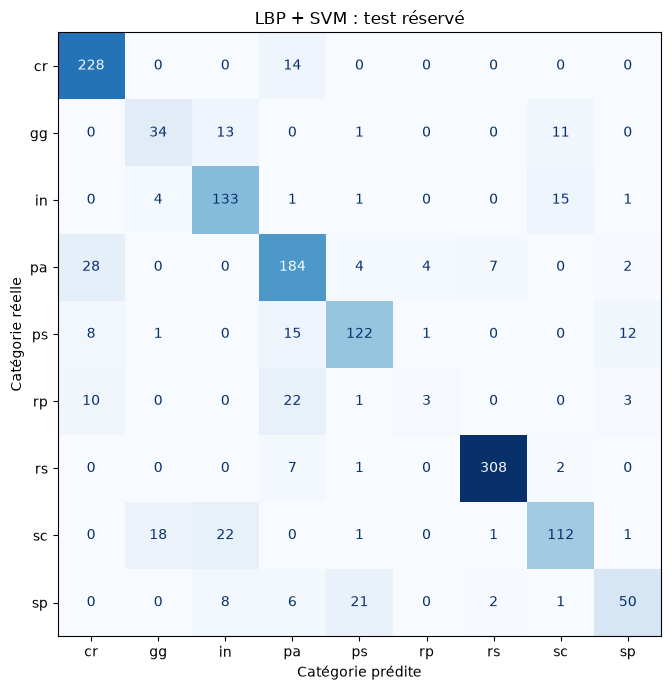

In [7]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)
y_pred = modele.predict(X_test)
mesures = {
    "accuracy_test": float(accuracy_score(y_test, y_pred)),
    "balanced_accuracy_test": float(balanced_accuracy_score(y_test, y_pred)),
    "f1_macro_test": float(f1_score(y_test, y_pred, average="macro", zero_division=0)),
    "f1_macro_validation": float(recherche.best_score_)
}
print(mesures)
print(classification_report(y_test, y_pred, labels=modele.classes_, digits=4, zero_division=0))
matrice = confusion_matrix(y_test, y_pred, labels=modele.classes_)
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(matrice, display_labels=modele.classes_).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_xlabel("Catégorie prédite")
ax.set_ylabel("Catégorie réelle")
ax.set_title("LBP + SVM : test réservé")
plt.tight_layout()
plt.show()


## 8. Démonstration sur le dossier test uniquement
Le chemin et les pixels sont vérifiés. Les images de train, validation et les fichiers externes sont refusés.

Origine : test réservé
Catégorie réelle : ps
Catégorie prédite : ps


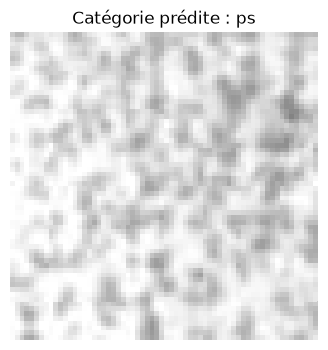

In [8]:
def demonstration(chemin):
    chemin = Path(chemin).resolve()
    autorises = {Path(chemins[i]).resolve(): i for i in idx_test}
    if chemin not in autorises:
        raise ValueError("Choisir une image dans le dossier test de cette exécution.")
    i = autorises[chemin]
    image, _, histogramme = calculer_lbp(chemin)
    empreinte = hashlib.sha256(str(image.shape).encode() + image.tobytes()).hexdigest()
    if empreinte != empreintes_images[i]:
        raise ValueError("Cette image a été modifiée depuis la séparation.")
    prediction = str(modele.predict(histogramme.reshape(1, -1))[0])
    print("Origine : test réservé")
    print("Catégorie réelle :", y[i])
    print("Catégorie prédite :", prediction)
    plt.figure(figsize=(4, 4))
    plt.imshow(image, cmap="gray", vmin=0, vmax=255)
    plt.title(f"Catégorie prédite : {prediction}")
    plt.axis("off")
    plt.show()
    return prediction

_ = demonstration(chemins[idx_test[0]])


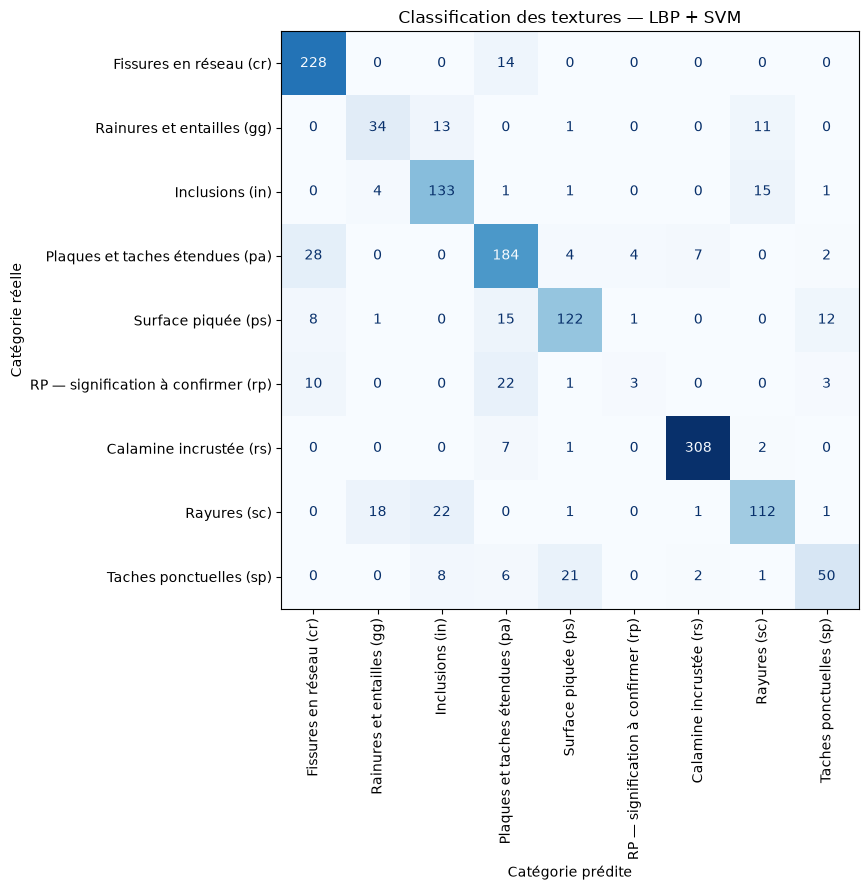

In [18]:
NOMS_CLASSES = {
    "cr": "Fissures en réseau",
    "gg": "Rainures et entailles",
    "in": "Inclusions",
    "pa": "Plaques et taches étendues",
    "ps": "Surface piquée",
    "rp": "RP — signification à confirmer",
    "rs": "Calamine incrustée",
    "sc": "Rayures",
    "sp": "Taches ponctuelles"
}

def nom_classe(code):
    return f"{NOMS_CLASSES.get(str(code), str(code))} ({code})"


# Afficher la matrice avec les noms français
noms = [nom_classe(c) for c in modele.classes_]

fig, ax = plt.subplots(figsize=(12, 9))
ConfusionMatrixDisplay(
    matrice, display_labels=noms
).plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=90)

ax.set_xlabel("Catégorie prédite")
ax.set_ylabel("Catégorie réelle")
ax.set_title("Classification des textures — LBP + SVM")
plt.tight_layout()
plt.show()


# Remplacer la démonstration précédente
def demonstration(chemin):
    chemin = Path(chemin).resolve()
    autorises = {
        Path(chemins[i]).resolve(): i
        for i in idx_test
    }

    if chemin not in autorises:
        raise ValueError(
            "Choisir une image dans le dossier test de cette exécution."
        )

    i = autorises[chemin]
    image, _, histogramme = calculer_lbp(chemin)

    empreinte = hashlib.sha256(
        str(image.shape).encode() + image.tobytes()
    ).hexdigest()

    if empreinte != empreintes_images[i]:
        raise ValueError("Cette image a été modifiée depuis la séparation.")

    prediction = str(
        modele.predict(histogramme.reshape(1, -1))[0]
    )

    print("Catégorie réelle :", nom_classe(y[i]))
    print("Catégorie prédite :", nom_classe(prediction))
    print("Résultat :", "Correct" if prediction == y[i] else "Incorrect")

    plt.figure(figsize=(6, 4))
    plt.imshow(image, cmap="gray", vmin=0, vmax=255)
    plt.title(f"Prédiction : {nom_classe(prediction)}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return prediction

## 9. Sauvegarde
Le pipeline sauvegardé contient le normaliseur et SVM. Le dossier resultats_TP_SVM préserve les résultats K-means. Les splits, paramètres et versions permettent de documenter l’expérience.

In [9]:
import json, joblib, sys
from importlib.metadata import version
SORTIE = DOSSIER_SPLIT / "resultats"
SORTIE.mkdir(parents=True, exist_ok=True)
joblib.dump({"modele": modele, "P": P, "R": R, "methode_lbp": "uniform",
             "bord_exclu": R, "pretraitement": "Pillow L uint8, sans redimensionnement"},
            SORTIE / "modele_lbp_svm.joblib")
np.savez_compressed(SORTIE / "donnees_experience.npz", X=X, y=y,
                    chemins=np.array(chemins), empreintes=empreintes_images,
                    idx_train=idx_train, idx_val=idx_val, idx_test=idx_test, chemins_source=chemins_source)
pd.DataFrame({"image": np.array(chemins)[idx_test], "categorie_reelle": y_test,
              "categorie_predite": y_pred}).to_csv(SORTIE / "predictions_test.csv", index=False)
resultats_cv.to_csv(SORTIE / "validation_fixe.csv", index=False)
pd.DataFrame(matrice, index=modele.classes_, columns=modele.classes_).to_csv(SORTIE / "matrice_confusion.csv")
mesures.update({"parametres": recherche.best_params_, "images_train": len(idx_train),
                "images_validation": len(idx_val), "images_test": len(idx_test), "doublons_ecartes": doublons,
                "versions": {p: version(p) for p in ["numpy", "scikit-learn", "scikit-image", "Pillow"]},
                "python": sys.version})
with open(SORTIE / "resultats.json", "w", encoding="utf-8") as f:
    json.dump(mesures, f, indent=2, ensure_ascii=False)
print("Sauvegarde :", SORTIE)


Sauvegarde : C:\Users\user\Desktop\RDF\dataset_SVM_20260909_091019_831131\resultats


## 10. Choisir un fichier image (facultatif)
Exécuter manuellement cette cellule pour ouvrir la fenêtre Windows.

Catégorie réelle : Calamine incrustée (rs)
Catégorie prédite : Calamine incrustée (rs)
Résultat : Correct


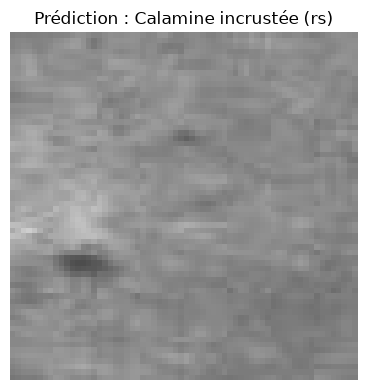

In [19]:
import tkinter as tk
from tkinter import filedialog

fenetre = tk.Tk()
fenetre.withdraw()
fenetre.attributes("-topmost", True)

try:
    image_choisie = filedialog.askopenfilename(
        parent=fenetre,
        title="Choisir une image de texture",
        initialdir=str(DOSSIER_SPLIT / "test"),
        filetypes=[
            ("Images", "*.jpg *.jpeg *.png *.bmp *.tif *.tiff")
        ]
    )
finally:
    fenetre.destroy()

if image_choisie:
    demonstration(image_choisie)
else:
    print("Sélection annulée.")